# Кейс 7. Аддитивная модель

В этом ноутбуке строится простая аддитивная модель, где многомерная зависимость приближается суммой одномерных функций. Компоненты задаются через полиномиальный базис.

## 1. Постановка задачи

Для признаков $X \in [0, 1]^p$ рассматривается модель

$$
\hat y = \beta_0 + \sum_{j=1}^{p} \hat g_j(x_j).
$$

На аддитивных данных истинная зависимость имеет вид

$$
y = \sin(2\pi x_1) + 0.5(x_2 - 0.5)^2 + \exp(-3x_3) + \varepsilon.
$$

Отдельно проверяется неаддитивная зависимость, где есть взаимодействие $x_1$ и $x_2$.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src").exists() and (ROOT / "functional_cases_lab" / "src").exists():
    ROOT = ROOT / "functional_cases_lab"
sys.path.insert(0, str(ROOT))

from src.case7_data import generate_additive_data, generate_nonadditive_data, true_components_on_grid
from src.case7_models import (
    additive_component_values,
    center_components,
    component_curves,
    evaluate_predictions,
    fit_additive_ols,
    fit_additive_ridge,
    fit_linear_model,
    fit_polynomial_model,
    predict_additive,
)
from src.plotting import plot_components, plot_error_curve, plot_true_vs_pred

RANDOM_STATE = 42
N_SAMPLES = 450
P_FEATURES = 3
TEST_SIZE = 0.25
NOISE = 0.10
M_BASIS = 6
RIDGE_ALPHA = 0.01
POLY_DEGREE = 3

np.random.seed(RANDOM_STATE)

## 2. Генерация аддитивных данных

Данные генерируются синтетически, поэтому известны истинные компоненты $g_1, g_2, g_3$. Это удобно для проверки графиков восстановленных функций.

In [2]:
X, y, true_components_train_all, y_clean = generate_additive_data(
    n_samples=N_SAMPLES,
    p=P_FEATURES,
    noise=NOISE,
    random_state=RANDOM_STATE,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

data_info = pd.DataFrame(
    {
        "object": ["X", "y", "X_train", "X_test"],
        "shape": [X.shape, y.shape, X_train.shape, X_test.shape],
        "min": [X.min(), y.min(), X_train.min(), X_test.min()],
        "max": [X.max(), y.max(), X_train.max(), X_test.max()],
    }
)
data_info

,object,shape,min,max
0,X,"(450, 3)",0.000519,0.999422
1,y,"(450,)",-1.008625,1.952856
2,X_train,"(337, 3)",0.000519,0.999422
3,X_test,"(113, 3)",0.001067,0.998743


In [3]:
pd.DataFrame(X[:5], columns=["x1", "x2", "x3"]).assign(y=y[:5]).round(3)

,x1,x2,x3,y
0,0.774,0.439,0.859,-0.830
1,0.697,0.094,0.976,-0.877
2,0.761,0.786,0.128,-0.235
3,0.450,0.371,0.927,0.434
4,0.644,0.823,0.443,-0.286


Все 450 объектов имеют три признака в
диапазоне $[0,1]$, поэтому дополнительное масштабирование не требуется.
Обучающая выборка содержит 337 объектов, тестовая — 113. Шум добавлен только к
ответу, а истинные компоненты сохранены для проверки восстановления.

## 3. Линейная модель

Обычная линейная регрессия используется как baseline. Она не моделирует нелинейность напрямую, но дает понятную нижнюю точку сравнения.

In [4]:
linear_model = fit_linear_model(X_train, y_train)
linear_eval = evaluate_predictions(linear_model, X_train, y_train, X_test, y_test)

linear_table = pd.DataFrame(
    [{"model": "Linear", **linear_eval["test"]}]
).round(4)
linear_table

,model,MSE,RMSE,R2
0,Linear,0.2245,0.4739,0.612


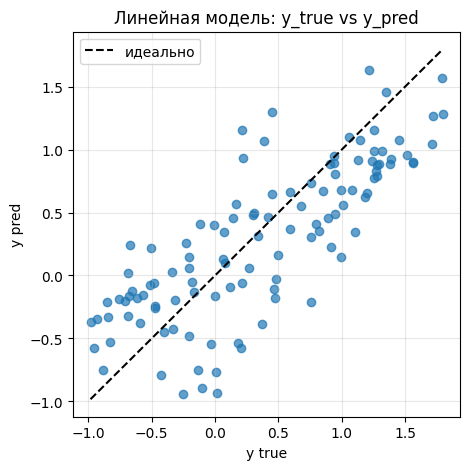

In [5]:
plot_true_vs_pred(y_test, linear_eval["pred_test"], title="Линейная модель: y_true vs y_pred")
plt.show()

**Рисунок 1. Истинные и
предсказанные значения линейной модели.**

Линейная модель описывает только общий тренд и не воспроизводит синусоидальную
зависимость. Поэтому ее test-RMSE равен $0.4739$, а $R^2=0.6120$: это заметно
хуже нелинейных моделей.

## 4. Аддитивная модель

Для каждого признака строится блок полиномиальных признаков $x_j, x_j^2, \dots, x_j^M$. Затем блоки склеиваются в одну матрицу $Z$.

In [6]:
add_ols = fit_additive_ols(X_train, y_train, degree=M_BASIS)
add_ridge = fit_additive_ridge(X_train, y_train, degree=M_BASIS, alpha=RIDGE_ALPHA)

add_ols_eval = evaluate_predictions(
    add_ols,
    X_train,
    y_train,
    X_test,
    y_test,
    predict_func=lambda model, X_part: predict_additive(model, X_part, M_BASIS),
)
add_ridge_eval = evaluate_predictions(
    add_ridge,
    X_train,
    y_train,
    X_test,
    y_test,
    predict_func=lambda model, X_part: predict_additive(model, X_part, M_BASIS),
)

additive_table = pd.DataFrame(
    [
        {"model": "Additive OLS", "M": M_BASIS, **add_ols_eval["test"]},
        {"model": "Additive Ridge", "M": M_BASIS, **add_ridge_eval["test"]},
    ]
).round(4)
additive_table

,model,M,MSE,RMSE,R2
0,Additive OLS,6,0.0114,0.1068,0.9803
1,Additive Ridge,6,0.0232,0.1523,0.9599


Аддитивная OLS значительно
улучшила качество: test-RMSE снизился с $0.4739$ до $0.1068$, а $R^2$ вырос с
$0.6120$ до $0.9803$. Ridge при выбранном $\lambda=0.01$ дал более слабый,
но все еще хороший результат ($RMSE=0.1523$). Причина преимущества
аддитивной модели — возможность отдельно описать нелинейную форму каждого
признака.

## 5. Центрирование компонент

Компоненты $g_j$ определены не единственным образом: константу можно перенести из одной компоненты в свободный член. Поэтому для графиков удобно вычитать среднее каждой компоненты на обучающей выборке.

In [7]:
component_values_train = additive_component_values(add_ridge, X_train, degree=M_BASIS)
centered_train, centered_intercept, component_means = center_components(
    component_values_train, add_ridge.intercept_
)

pred_original = predict_additive(add_ridge, X_train, M_BASIS)
pred_centered = centered_intercept + centered_train.sum(axis=1)
max_prediction_diff = np.max(np.abs(pred_original - pred_centered))

pd.DataFrame(
    {
        "check": ["max difference after centering"],
        "value": [max_prediction_diff],
    }
)

,check,value
0,max difference after centering,4.884981e-15


Максимальная
разница предсказаний до и после центрирования равна
$4.9\cdot10^{-15}$. Это численный ноль: средние компонент перенесены в
свободный член, поэтому форма представления изменилась, а прогнозы — нет.

## 6. Восстановление функций $g_j$

Построим оцененные компоненты на равномерной сетке. Истинные компоненты также центрируются по среднему на сетке, чтобы сравнивать в основном форму графиков.

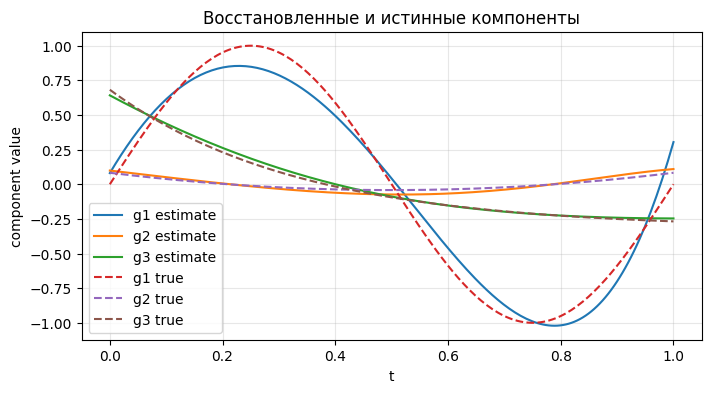

In [8]:
grid = np.linspace(0.0, 1.0, 200)
estimated_curves = component_curves(
    add_ridge,
    degree=M_BASIS,
    p=P_FEATURES,
    grid=grid,
    centers=component_means,
)

true_curves = true_components_on_grid(grid)
true_curves_centered = true_curves - true_curves.mean(axis=1, keepdims=True)

plot_components(
    grid,
    estimated_curves,
    labels=["g1", "g2", "g3"],
    true_components=true_curves_centered,
    title="Восстановленные и истинные компоненты",
)
plt.show()

**Рисунок 2.
Восстановленные и истинные центрированные компоненты.**

Оценки правильно передают основные формы: $g_1$ остается синусоидальной,
$g_2$ — слабой U-образной, $g_3$ — убывающей. Лучше всего восстановлена
$g_3$. У $g_1$ заметны сглаживание амплитуды и краевой выброс около $x=1$, а
эффект $g_2$ мал по сравнению с шумом, поэтому его форма оценивается менее
уверенно. Вертикальные сдвиги не сравниваются из-за центрирования.

## 7. Сравнение с полной полиномиальной моделью

Полная полиномиальная модель содержит не только степени отдельных признаков, но и взаимодействия. Она менее интерпретируема как сумма компонент, зато может описывать более широкий класс зависимостей.

In [9]:
poly_model = fit_polynomial_model(X_train, y_train, degree=POLY_DEGREE, alpha=RIDGE_ALPHA)
poly_eval = evaluate_predictions(poly_model, X_train, y_train, X_test, y_test)

poly_features_count = poly_model.named_steps["polynomialfeatures"].n_output_features_
models_table = pd.DataFrame(
    [
        {"model": "Linear", "n_parameters": linear_model.coef_.size + 1, **linear_eval["test"]},
        {"model": "Additive Ridge", "n_parameters": add_ridge.coef_.size + 1, **add_ridge_eval["test"]},
        {"model": "Polynomial Ridge", "n_parameters": poly_features_count + 1, **poly_eval["test"]},
    ]
).round(4)
models_table

,model,n_parameters,MSE,RMSE,R2
0,Linear,4,0.2245,0.4739,0.6120
1,Additive Ridge,19,0.0232,0.1523,0.9599
2,Polynomial Ridge,20,0.0281,0.1676,0.9515


На аддитивных
данных Additive Ridge немного лучше полной Polynomial Ridge:
$RMSE=0.1523$ против $0.1676$ при почти одинаковом числе параметров (19 и 20).
Взаимодействия здесь не нужны, поэтому аддитивная модель одновременно точнее и
проще для интерпретации.

## 8. Влияние числа базисных функций

Проверим несколько значений $M$, то есть число степеней полинома для каждой компоненты.

In [10]:
M_values = [1, 2, 3, 5, 7, 10, 12]
M_rows = []

for M in M_values:
    model = fit_additive_ridge(X_train, y_train, degree=M, alpha=RIDGE_ALPHA)
    result = evaluate_predictions(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        predict_func=lambda fitted_model, X_part, M_current=M: predict_additive(fitted_model, X_part, M_current),
    )
    M_rows.append(
        {
            "M": M,
            "train_RMSE": result["train"]["RMSE"],
            "test_RMSE": result["test"]["RMSE"],
            "test_R2": result["test"]["R2"],
        }
    )

M_table = pd.DataFrame(M_rows)
M_table.round(4)

,M,train_RMSE,test_RMSE,test_R2
0,1,0.4422,0.4738,0.6121
1,2,0.4311,0.4743,0.6113
2,3,0.1564,0.1736,0.9479
3,5,0.1495,0.1599,0.9558
4,7,0.1302,0.1381,0.9670
5,10,0.1145,0.1196,0.9753
6,12,0.1167,0.1215,0.9745


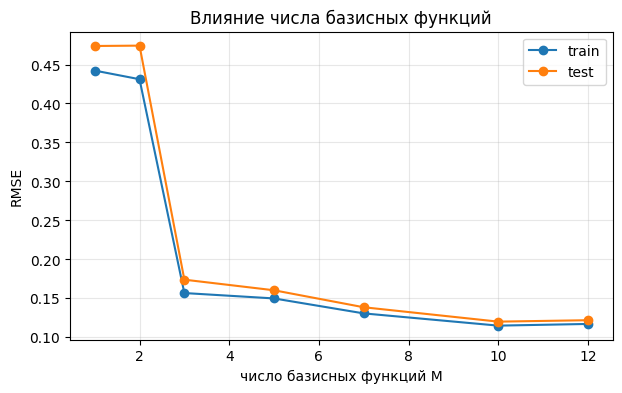

In [11]:
plot_error_curve(
    M_table["M"],
    M_table["train_RMSE"],
    M_table["test_RMSE"],
    xlabel="число базисных функций M",
    ylabel="RMSE",
    title="Влияние числа базисных функций",
)
plt.show()

**Рисунок 3.
Зависимость RMSE от числа базисных функций $M$.**

При $M=1$ и $M=2$ модель недообучается: test-RMSE около $0.474$. Начиная с
$M=3$ ошибка резко уменьшается, а лучший результат в проверенной сетке получен
при $M=10$ ($RMSE=0.1196$). При $M=12$ ошибка немного растет до $0.1215$.
Поэтому разумный диапазон для этого эксперимента — $M=5\ldots10$; выбранное
$M=6$ дает хороший компромисс между качеством и простотой.

## 9. Эксперимент на неаддитивных данных

Теперь данные генерируются по формуле

$$
y = \sin(2\pi(x_1 + x_2)) + 0.5x_3 + \varepsilon.
$$

В этой зависимости вклад $x_1$ и $x_2$ нельзя полностью разделить на сумму двух независимых одномерных функций.

In [12]:
X_non, y_non, y_non_clean = generate_nonadditive_data(
    n_samples=N_SAMPLES,
    p=P_FEATURES,
    noise=NOISE,
    random_state=RANDOM_STATE,
)
Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_non, y_non, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

linear_non = fit_linear_model(Xn_train, yn_train)
add_non = fit_additive_ridge(Xn_train, yn_train, degree=M_BASIS, alpha=RIDGE_ALPHA)
poly_non = fit_polynomial_model(Xn_train, yn_train, degree=POLY_DEGREE, alpha=RIDGE_ALPHA)

linear_non_eval = evaluate_predictions(linear_non, Xn_train, yn_train, Xn_test, yn_test)
add_non_eval = evaluate_predictions(
    add_non,
    Xn_train,
    yn_train,
    Xn_test,
    yn_test,
    predict_func=lambda model, X_part: predict_additive(model, X_part, M_BASIS),
)
poly_non_eval = evaluate_predictions(poly_non, Xn_train, yn_train, Xn_test, yn_test)

nonadditive_table = pd.DataFrame(
    [
        {"data": "nonadditive", "model": "Linear", **linear_non_eval["test"]},
        {"data": "nonadditive", "model": "Additive Ridge", **add_non_eval["test"]},
        {"data": "nonadditive", "model": "Polynomial Ridge", **poly_non_eval["test"]},
    ]
).round(4)
nonadditive_table

,data,model,MSE,RMSE,R2
0,nonadditive,Linear,0.5450,0.7383,0.1147
1,nonadditive,Additive Ridge,0.5824,0.7631,0.0540
2,nonadditive,Polynomial Ridge,0.2625,0.5123,0.5737


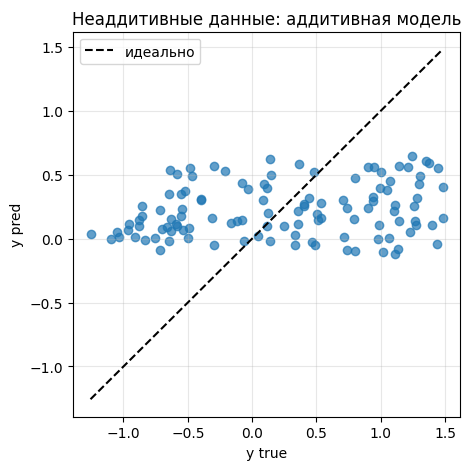

In [13]:
plot_true_vs_pred(
    yn_test,
    add_non_eval["pred_test"],
    title="Неаддитивные данные: аддитивная модель",
)
plt.show()

**Рисунок
4. Предсказания аддитивной модели на неаддитивных данных.**

На данных со взаимодействием $x_1$ и $x_2$ аддитивная модель не смогла
разделить сигнал на независимые компоненты и получила $R^2=0.0540$, даже хуже
линейной модели ($0.1147$). Polynomial Ridge учитывает взаимодействия и
повысила $R^2$ до $0.5737$, хотя полином третьей степени все равно не полностью
описывает синусоидальную зависимость.

## 10. Явный вид блочной матрицы признаков

В матрице $Z$ последовательно расположены блоки степеней каждого признака.
Свободный член не включается в $Z$, поскольку его отдельно оценивает модель.

In [14]:
from src.case7_basis import build_additive_features

Z_add_train = build_additive_features(X_train, degree=M_BASIS)
column_names = [
    f"x{feature + 1}^{power}"
    for feature in range(P_FEATURES)
    for power in range(1, M_BASIS + 1)
]

display(pd.DataFrame({"object": ["Z_add_train"], "shape": [Z_add_train.shape]}))
pd.DataFrame(Z_add_train[:5], columns=column_names).round(3)

,object,shape
0,Z_add_train,"(337, 18)"


,x1^1,x1^2,x1^3,x1^4,x1^5,x1^6,x2^1,x2^2,x2^3,x2^4,x2^5,x2^6,x3^1,x3^2,x3^3,x3^4,x3^5,x3^6
0,0.393,0.154,0.061,0.024,0.009,0.004,0.875,0.766,0.670,0.586,0.513,0.449,0.976,0.952,0.929,0.906,0.884,0.862
1,0.408,0.166,0.068,0.028,0.011,0.005,0.094,0.009,0.001,0.000,0.000,0.000,0.890,0.791,0.704,0.626,0.557,0.496
2,0.682,0.466,0.318,0.217,0.148,0.101,0.140,0.020,0.003,0.000,0.000,0.000,0.200,0.040,0.008,0.002,0.000,0.000
3,0.888,0.789,0.701,0.623,0.553,0.492,0.930,0.864,0.803,0.747,0.694,0.646,0.100,0.010,0.001,0.000,0.000,0.000
4,0.383,0.147,0.056,0.022,0.008,0.003,0.730,0.532,0.389,0.283,0.207,0.151,0.553,0.306,0.169,0.094,0.052,0.029


## 11. Выводы по выбору модели

- Для аддитивных данных разумно использовать $M$ от 5 до 10. Меньшие значения
  не передают синусоидальную компоненту, а после $M=10$ улучшение прекращается.
- Восстановленные компоненты передают ожидаемые формы, но слабая компонента
  $g_2$ и края отрезка оцениваются хуже.
- Аддитивная модель подходит, когда отклик действительно является суммой
  одномерных эффектов. При наличии взаимодействий нужна более общая модель.
- Число базисных функций и коэффициент регуляризации в прикладной задаче
  следует выбирать по validation-выборке или кросс-валидации.

## 12. Итоговые наблюдения

На аддитивных данных модель с полиномиальными компонентами намного лучше
линейного baseline и позволяет отдельно рассмотреть влияние каждого признака.
Additive OLS показала лучший основной результат ($RMSE=0.1068$,
$R^2=0.9803$). Центрирование сделало компоненты сравнимыми и не изменило
предсказания. Эксперимент на неаддитивных данных показал главное ограничение:
без явных взаимодействий аддитивная модель не может описать совместный эффект
$x_1$ и $x_2$.